In [6]:
# Cell 1: Direct download - no Kaggle account/file-picker needed
!wget https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv


--2026-08-19 06:18:30--  https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1423529 (1.4M) [text/plain]
Saving to: ‘housing.csv.1’

housing.csv.1       100%[===================>]   1.36M  --.-KB/s    in 0.02s   

2026-08-19 06:18:30 (56.5 MB/s) - ‘housing.csv.1’ saved [1423529/1423529]



In [7]:
# Cell 2: Libraries import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [8]:
# Cell 3: Dataset load
df = pd.read_csv('housing.csv')
print("Shape:", df.shape)
df.head()

Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [9]:
# Cell 4: Basic info
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


**Step 1: Data Cleaning**

In [10]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [11]:
median_bedrooms = df['total_bedrooms'].median()
df['total_bedrooms'].fillna(median_bedrooms, inplace=True)

# Verify
df.isnull().sum()

/tmp/ipykernel_673/1729188822.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_bedrooms'].fillna(median_bedrooms, inplace=True)


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [12]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [13]:
df['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [14]:
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


**Step 2: Exploratory Data Analysis (EDA)**

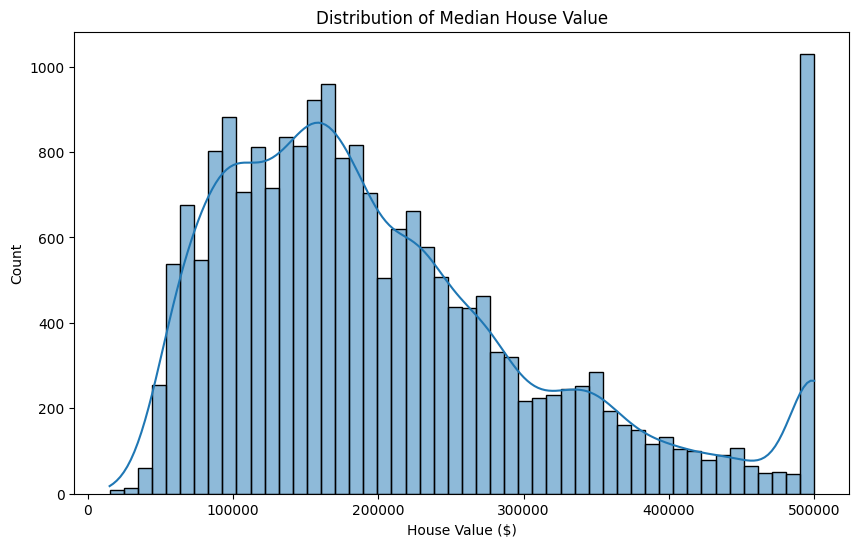

In [15]:
plt.figure(figsize=(10,6))
sns.histplot(df['median_house_value'], bins=50, kde=True)
plt.title('Distribution of Median House Value')
plt.xlabel('House Value ($)')
plt.show()

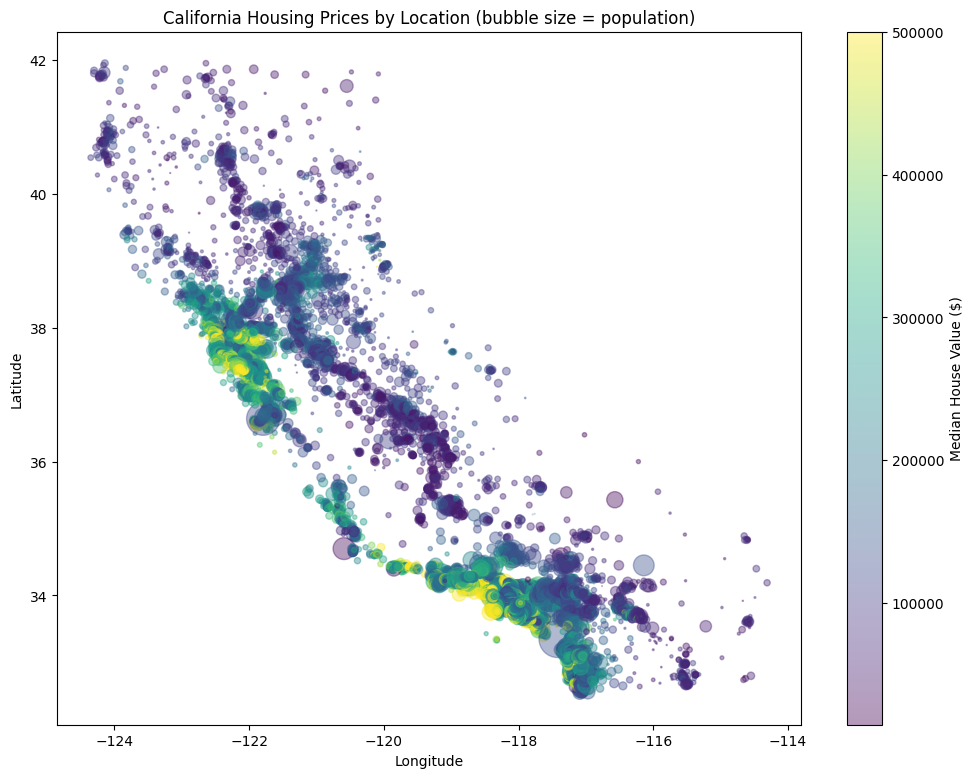

In [16]:
plt.figure(figsize=(12,9))
plt.scatter(df['longitude'], df['latitude'],
            c=df['median_house_value'], cmap='viridis',
            alpha=0.4, s=df['population']/50)
plt.colorbar(label='Median House Value ($)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('California Housing Prices by Location (bubble size = population)')
plt.show()

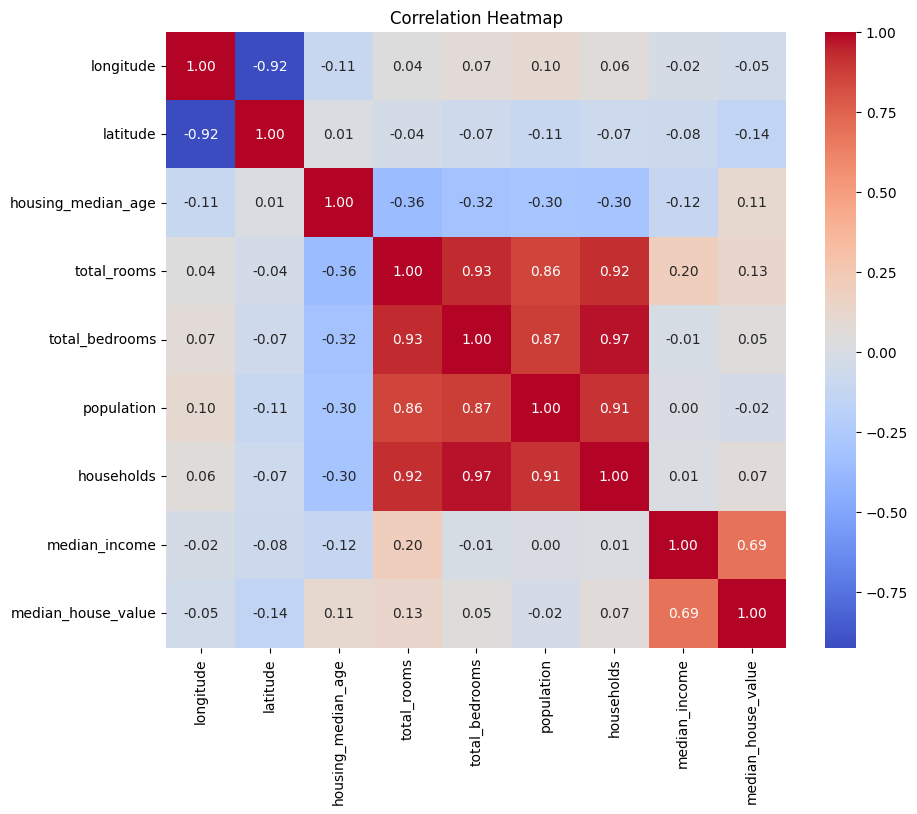

In [17]:
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [18]:
correlations = numeric_df.corr()['median_house_value'].sort_values(ascending=False)
print(correlations)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049457
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


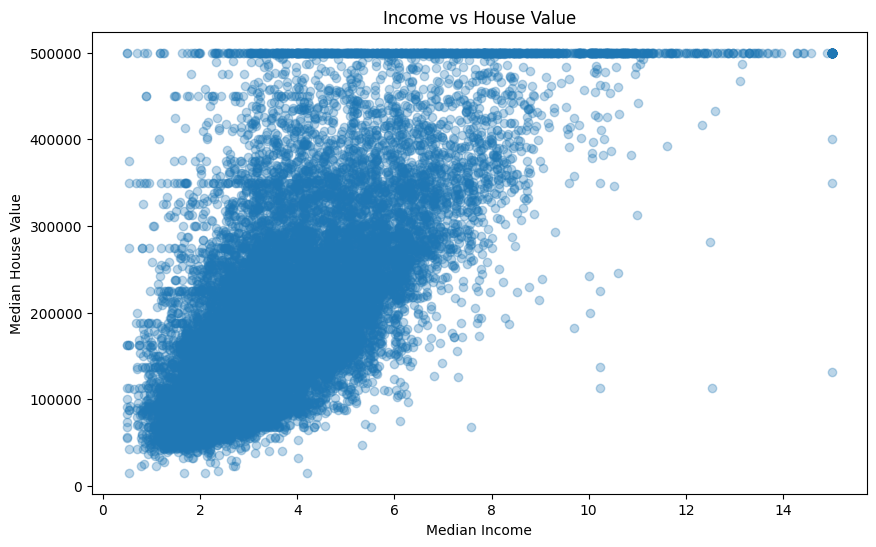

In [19]:
plt.figure(figsize=(10,6))
plt.scatter(df['median_income'], df['median_house_value'], alpha=0.3)
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Income vs House Value')
plt.show()

In [20]:
df.groupby([c for c in df.columns if c.startswith('ocean_proximity')]).size()

ocean_proximity_INLAND  ocean_proximity_ISLAND  ocean_proximity_NEAR BAY  ocean_proximity_NEAR OCEAN
False                   False                   False                     False                         9136
                                                                          True                          2658
                                                True                      False                         2290
                        True                    False                     False                            5
True                    False                   False                     False                         6551
dtype: int64

**Step 3: Feature Selection + Train-Test Split**

In [21]:
# Separate features and target variable
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20640, 12)
y shape: (20640,)


In [22]:
from sklearn.model_selection import train_test_split

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (16512, 12)
Testing set: (4128, 12)


In [23]:
from sklearn.preprocessing import StandardScaler

# Scale features so they are on a similar range
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done. Mean of scaled training data:", X_train_scaled.mean().round(2))
print("Std of scaled training data:", X_train_scaled.std().round(2))

Scaling done. Mean of scaled training data: 0.0
Std of scaled training data: 1.0


**Step 4: Model Building**

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

In [25]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# Dictionary of regression models to compare
regressors = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'DecisionTree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
}

In [26]:
results = []

for name, model in regressors.items():
    start = time.time()
    model.fit(X_train_scaled, y_train)
    end = time.time()

    y_pred = model.predict(X_test_scaled)

    # Regression metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2,
        'Training Time (s)': end - start
    })

    print(f"{name} -> RMSE: {rmse:.2f} | R2: {r2:.4f} | Time: {end-start:.2f}s")

LinearRegression -> RMSE: 70060.52 | R2: 0.6254 | Time: 0.07s
Ridge -> RMSE: 70057.42 | R2: 0.6255 | Time: 0.02s
Lasso -> RMSE: 70059.85 | R2: 0.6254 | Time: 0.29s
DecisionTree -> RMSE: 61497.16 | R2: 0.7114 | Time: 0.68s
RandomForest -> RMSE: 49008.79 | R2: 0.8167 | Time: 26.10s
GradientBoosting -> RMSE: 55888.27 | R2: 0.7616 | Time: 7.00s
KNN -> RMSE: 61367.04 | R2: 0.7126 | Time: 0.03s
XGBoost -> RMSE: 48266.27 | R2: 0.8222 | Time: 0.38s


In [27]:
from sklearn.utils import resample

# Use a smaller subset since SVR is slow on large datasets
X_train_small, y_train_small = resample(X_train_scaled, y_train, n_samples=3000, random_state=42)

start = time.time()
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train_small, y_train_small)
end = time.time()

y_pred_svr = svr_model.predict(X_test_scaled)
svr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_svr))
svr_r2 = r2_score(y_test, y_pred_svr)

print(f"SVR (3k subset) -> RMSE: {svr_rmse:.2f} | R2: {svr_r2:.4f} | Time: {end-start:.2f}s")

results.append({'Model': 'SVR (3k subset)', 'MAE': mean_absolute_error(y_test, y_pred_svr),
                 'RMSE': svr_rmse, 'R2 Score': svr_r2, 'Training Time (s)': end-start})

SVR (3k subset) -> RMSE: 116639.92 | R2: -0.0382 | Time: 0.50s


In [28]:
results_df = pd.DataFrame(results).sort_values('R2 Score', ascending=False)
results_df

,Model,MAE,RMSE,R2 Score,Training Time (s)
7,XGBoost,31887.392086,48266.270265,0.822221,0.384631
4,RandomForest,31631.018675,49008.789216,0.816709,26.097498
5,GradientBoosting,38248.738775,55888.265159,0.761639,7.000598
6,KNN,40854.397771,61367.037403,0.712615,0.031214
3,DecisionTree,40766.510478,61497.159821,0.711395,0.679641
1,Ridge,50668.122931,70057.416870,0.625457,0.017492
2,Lasso,50670.132336,70059.851178,0.625431,0.287211
0,LinearRegression,50670.738241,70060.521845,0.625424,0.067633
8,SVR (3k subset),87375.463271,116639.917285,-0.038216,0.500260


/tmp/ipykernel_673/1131161940.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='R2 Score', palette='Blues_d')


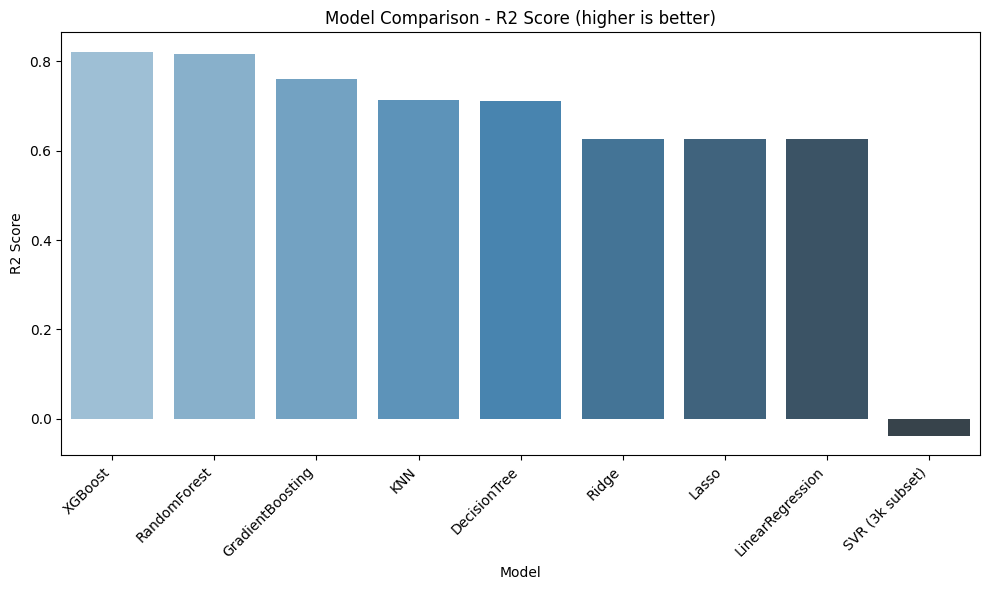

In [29]:
plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x='Model', y='R2 Score', palette='Blues_d')
plt.xticks(rotation=45, ha='right')
plt.title('Model Comparison - R2 Score (higher is better)')
plt.tight_layout()
plt.show()

**Step 5: Model Evaluation**

In [30]:
# Automatically pick the best model based on R2 Score
best_model_name = results_df.iloc[0]['Model']
print("Best Model:", best_model_name)

all_models = regressors.copy()
all_models['SVR (3k subset)'] = svr_model
best_model = all_models[best_model_name]

Best Model: XGBoost


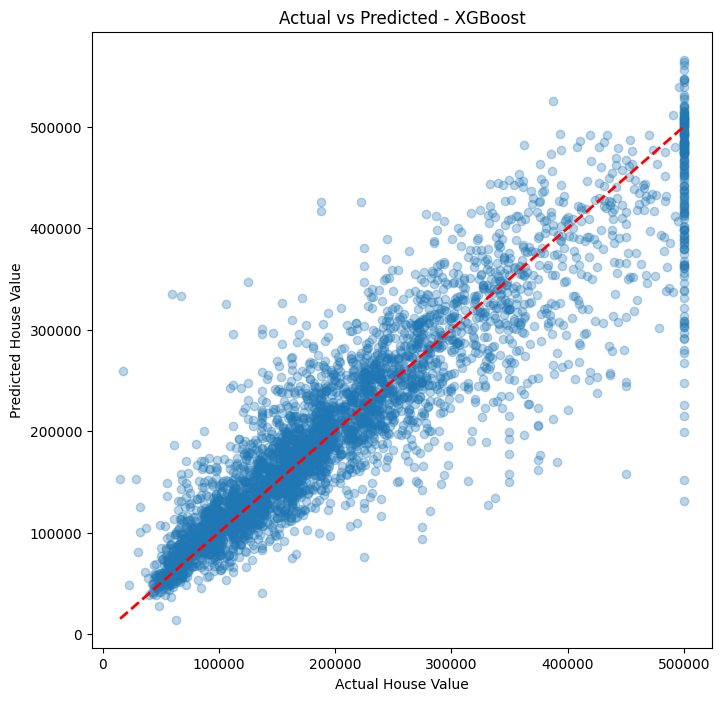

In [31]:
y_pred_best = best_model.predict(X_test_scaled)

plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred_best, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual House Value')
plt.ylabel('Predicted House Value')
plt.title(f'Actual vs Predicted - {best_model_name}')
plt.show()

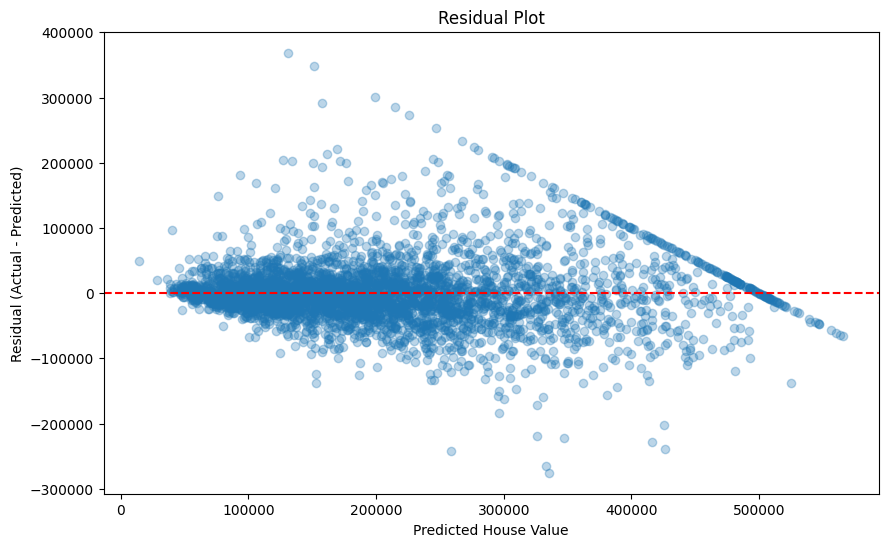

In [32]:
residuals = y_test - y_pred_best

plt.figure(figsize=(10,6))
plt.scatter(y_pred_best, residuals, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted House Value')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')
plt.show()

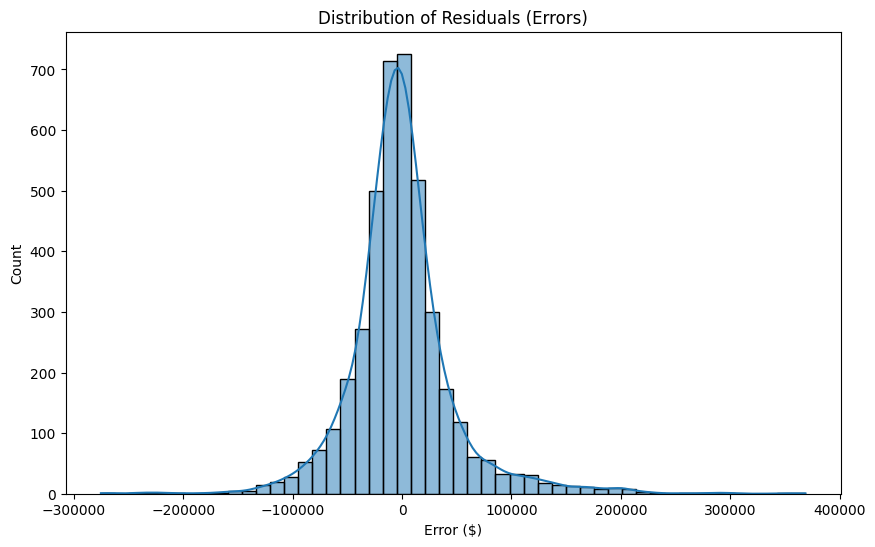

In [33]:
plt.figure(figsize=(10,6))
sns.histplot(residuals, bins=50, kde=True)
plt.title('Distribution of Residuals (Errors)')
plt.xlabel('Error ($)')
plt.show()

/tmp/ipykernel_673/3912005746.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


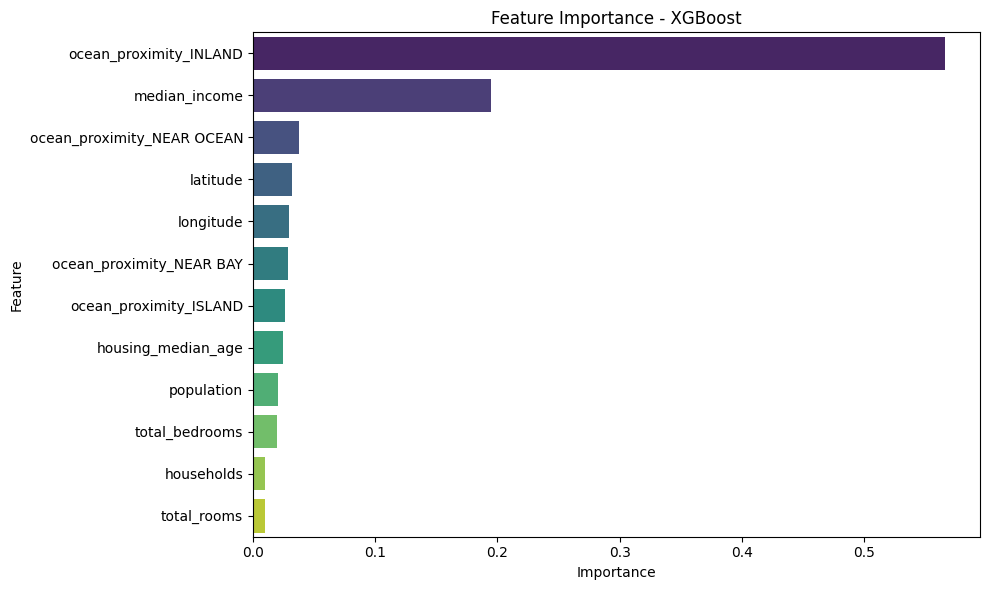

                       Feature  Importance
8       ocean_proximity_INLAND    0.566359
7                median_income    0.194357
11  ocean_proximity_NEAR OCEAN    0.038016
1                     latitude    0.031703
0                    longitude    0.029657
10    ocean_proximity_NEAR BAY    0.028786
9       ocean_proximity_ISLAND    0.026010
2           housing_median_age    0.024350
5                   population    0.020634
4               total_bedrooms    0.020089
6                   households    0.010237
3                  total_rooms    0.009801


In [34]:
# This only works for tree-based models (RandomForest, GradientBoosting, XGBoost, DecisionTree)
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10,6))
    sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
    plt.title(f'Feature Importance - {best_model_name}')
    plt.tight_layout()
    plt.show()

    print(importance_df)
else:
    print("Best model does not support feature importance directly (e.g. Linear Regression, SVR).")

**Step 6: Model Improvement**

In [35]:
# Create new engineered features from existing columns
df_improved = df.copy()

df_improved['rooms_per_household'] = df_improved['total_rooms'] / df_improved['households']
df_improved['bedrooms_per_room'] = df_improved['total_bedrooms'] / df_improved['total_rooms']
df_improved['population_per_household'] = df_improved['population'] / df_improved['households']

df_improved[['rooms_per_household', 'bedrooms_per_room', 'population_per_household']].describe()

,rooms_per_household,bedrooms_per_room,population_per_household
count,20640.000000,20640.000000,20640.000000
mean,5.429000,0.213794,3.070655
std,2.474173,0.065248,10.386050
min,0.846154,0.037151,0.692308
25%,4.440716,0.175225,2.429741
50%,5.229129,0.203159,2.818116
75%,6.052381,0.240126,3.282261
max,141.909091,2.824675,1243.333333


In [36]:
# Split features and target again with the new engineered features
X_improved = df_improved.drop('median_house_value', axis=1)
y_improved = df_improved['median_house_value']

X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_improved, y_improved, test_size=0.2, random_state=42)

scaler_imp = StandardScaler()
X_train_imp_scaled = scaler_imp.fit_transform(X_train_imp)
X_test_imp_scaled = scaler_imp.transform(X_test_imp)

# Retrain the best-performing model type with the new features
from sklearn.ensemble import RandomForestRegressor
rf_improved = RandomForestRegressor(n_estimators=100, random_state=42)
rf_improved.fit(X_train_imp_scaled, y_train_imp)

y_pred_imp = rf_improved.predict(X_test_imp_scaled)
r2_improved = r2_score(y_test_imp, y_pred_imp)
rmse_improved = np.sqrt(mean_squared_error(y_test_imp, y_pred_imp))

print(f"Improved RandomForest -> RMSE: {rmse_improved:.2f} | R2: {r2_improved:.4f}")
print(f"Previous best R2 was: {results_df.iloc[0]['R2 Score']:.4f}")

Improved RandomForest -> RMSE: 50258.95 | R2: 0.8072
Previous best R2 was: 0.8222


In [37]:
from sklearn.model_selection import GridSearchCV

# Try a small grid of hyperparameters to find the best combination
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train_imp_scaled, y_train_imp)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation R2:", grid_search.best_score_)

Best parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation R2: 0.8079209162086164


In [38]:
final_model = grid_search.best_estimator_
y_pred_final = final_model.predict(X_test_imp_scaled)

final_r2 = r2_score(y_test_imp, y_pred_final)
final_rmse = np.sqrt(mean_squared_error(y_test_imp, y_pred_final))

print(f"Final Tuned Model -> RMSE: {final_rmse:.2f} | R2: {final_r2:.4f}")

Final Tuned Model -> RMSE: 50147.40 | R2: 0.8081


In [39]:
import pickle

pickle.dump(final_model, open('housing_model.pkl', 'wb'))
pickle.dump(scaler_imp, open('housing_scaler.pkl', 'wb'))

print("Model and scaler saved successfully.")

Model and scaler saved successfully.


In [40]:
from google.colab import files
files.download('housing_model.pkl')
files.download('housing_scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
# Cell 34: Save the exact feature column order (needed for correct predictions later)
feature_columns = X_improved.columns.tolist()
pickle.dump(feature_columns, open('feature_columns.pkl', 'wb'))
print(feature_columns)

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']


In [42]:
files.download('feature_columns.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
# Pick a random real sample and compare its actual vs predicted price
sample = df.sample(1, random_state=1)
print(sample)
print("\nActual price:", sample['median_house_value'].values[0])

      longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
4712    -118.36     34.06                39.0       2810.0           670.0   

      population  households  median_income  median_house_value  \
4712      1109.0       624.0           3.25            355000.0   

      ocean_proximity_INLAND  ocean_proximity_ISLAND  \
4712                   False                   False   

      ocean_proximity_NEAR BAY  ocean_proximity_NEAR OCEAN  
4712                     False                       False  

Actual price: 355000.0


In [44]:
# Retrain with controlled size (capped depth + fewer trees)
from sklearn.ensemble import RandomForestRegressor
import joblib

final_model_small = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,        # capped, instead of unlimited
    min_samples_split=5,
    random_state=42
)
final_model_small.fit(X_train_imp_scaled, y_train_imp)

y_pred_small = final_model_small.predict(X_test_imp_scaled)
print("R2 Score:", r2_score(y_test_imp, y_pred_small))
print("RMSE:", np.sqrt(mean_squared_error(y_test_imp, y_pred_small)))

R2 Score: 0.8018394651947852
RMSE: 50957.957567172154


In [45]:
#  Save using joblib WITH compression (much smaller file than pickle)
joblib.dump(final_model_small, 'housing_model.pkl', compress=3)

import os
size_mb = os.path.getsize('housing_model.pkl') / (1024*1024)
print(f"New file size: {size_mb:.2f} MB")

New file size: 8.56 MB


In [46]:
files.download('housing_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>